In [182]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [183]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
df=pd.read_csv("Housing price prediction.csv")

In [184]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [186]:
df.duplicated().sum()


np.int64(0)

In [187]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


<Axes: >

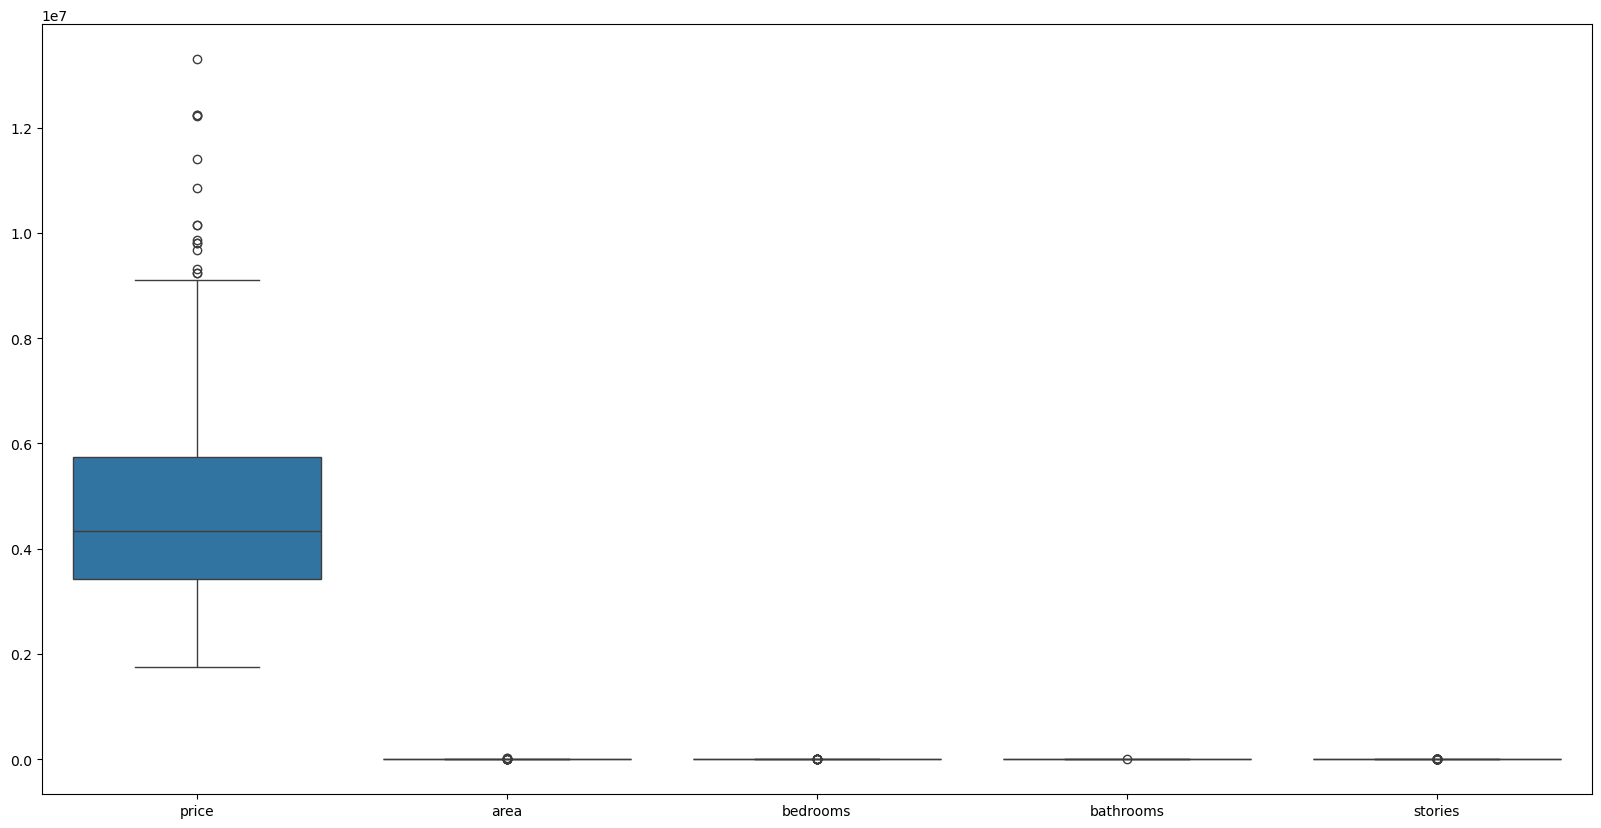

In [188]:
plt.figure(figsize=(20, 10)) 
sns.boxplot(data=df[['price','area','bedrooms','bathrooms','stories']])

In [189]:
data=df.copy()

In [190]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [191]:
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data.loc[data[col] < lower_bound, col] = lower_bound
    data.loc[data[col] > upper_bound, col] = upper_bound

    return data

data = cap_outliers(data, 'price')
data = cap_outliers(data, 'area')
data = cap_outliers(data, 'bedrooms')
data = cap_outliers(data, 'bathrooms')
data = cap_outliers(data, 'stories')

C:\Users\SITARAM\AppData\Local\Temp\ipykernel_12520\2319535398.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data[col] < lower_bound, col] = lower_bound
C:\Users\SITARAM\AppData\Local\Temp\ipykernel_12520\2319535398.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data[col] < lower_bound, col] = lower_bound
C:\Users\SITARAM\AppData\Local\Temp\ipykernel_12520\2319535398.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data[co

<Axes: >

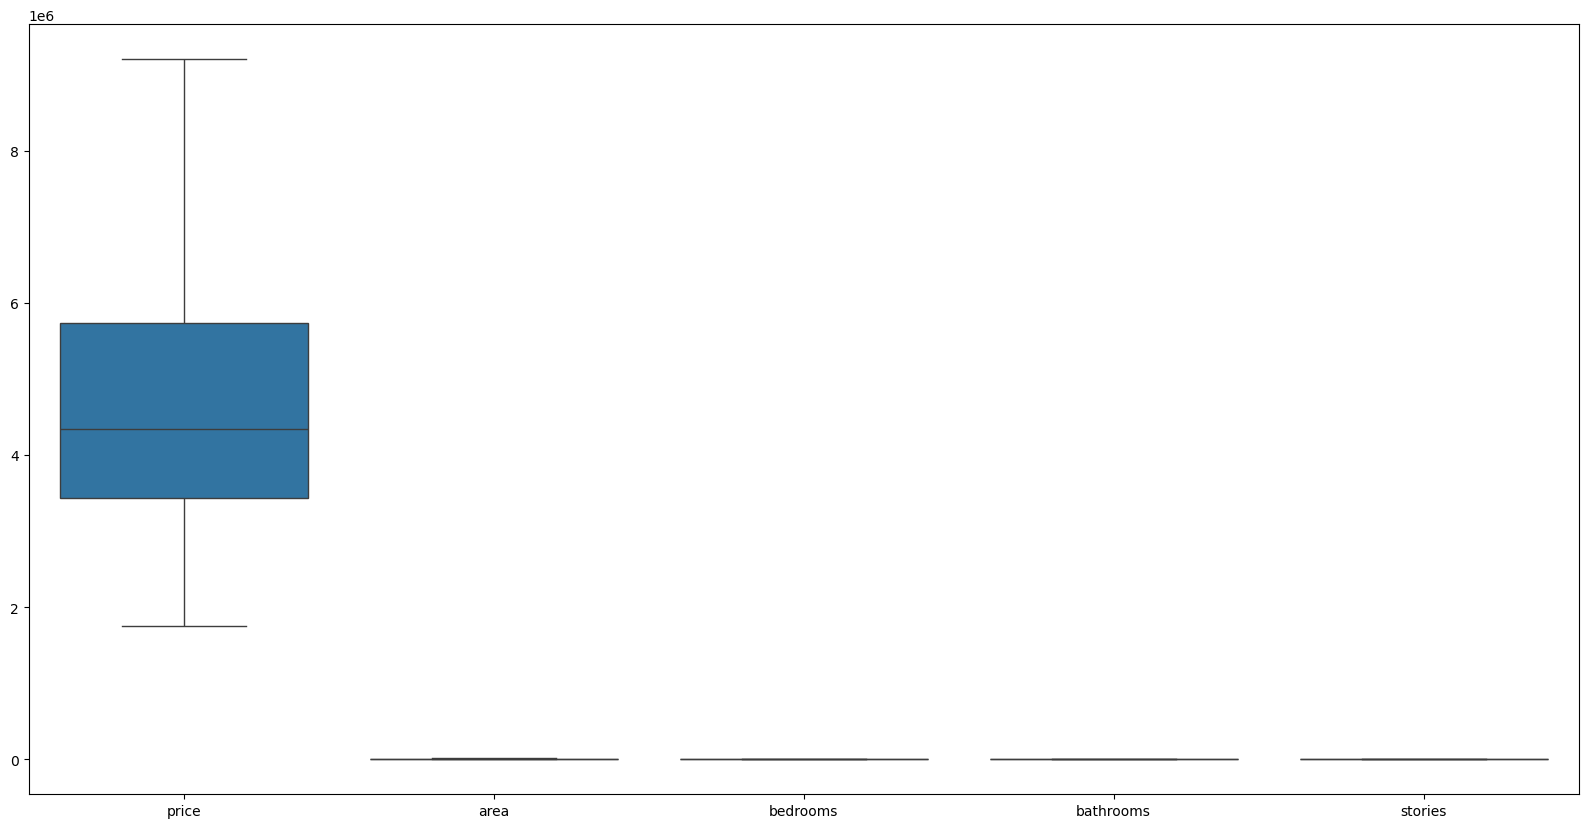

In [192]:
plt.figure(figsize=(20, 10)) 
sns.boxplot(data=data[['price','area','bedrooms','bathrooms','stories']])

In [193]:
# List all binary columns from your image
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# Apply the mapping to all at once
data[binary_cols] = data[binary_cols].apply(lambda x: x.map({'yes': 1, 'no': 0}))

In [194]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,9205000,7420,4.0,2.0,3.0,1,0,0,0,1,2,1,furnished
1,9205000,8960,4.0,3.5,3.5,1,0,0,0,1,3,0,furnished
2,9205000,9960,3.0,2.0,2.0,1,0,1,0,0,2,1,semi-furnished
3,9205000,7500,4.0,2.0,2.0,1,0,1,0,1,3,1,furnished
4,9205000,7420,4.0,1.0,2.0,1,1,1,0,1,2,0,furnished


In [195]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    int64  
 1   area              545 non-null    int64  
 2   bedrooms          545 non-null    float64
 3   bathrooms         545 non-null    float64
 4   stories           545 non-null    float64
 5   mainroad          545 non-null    int64  
 6   guestroom         545 non-null    int64  
 7   basement          545 non-null    int64  
 8   hotwaterheating   545 non-null    int64  
 9   airconditioning   545 non-null    int64  
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    int64  
 12  furnishingstatus  545 non-null    object 
dtypes: float64(3), int64(9), object(1)
memory usage: 55.5+ KB


In [196]:
data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)

In [197]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,9205000,7420,4.0,2.0,3.0,1,0,0,0,1,2,1,False,False
1,9205000,8960,4.0,3.5,3.5,1,0,0,0,1,3,0,False,False
2,9205000,9960,3.0,2.0,2.0,1,0,1,0,0,2,1,True,False
3,9205000,7500,4.0,2.0,2.0,1,0,1,0,1,3,1,False,False
4,9205000,7420,4.0,1.0,2.0,1,1,1,0,1,2,0,False,False


In [198]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price                            545 non-null    int64  
 1   area                             545 non-null    int64  
 2   bedrooms                         545 non-null    float64
 3   bathrooms                        545 non-null    float64
 4   stories                          545 non-null    float64
 5   mainroad                         545 non-null    int64  
 6   guestroom                        545 non-null    int64  
 7   basement                         545 non-null    int64  
 8   hotwaterheating                  545 non-null    int64  
 9   airconditioning                  545 non-null    int64  
 10  parking                          545 non-null    int64  
 11  prefarea                         545 non-null    int64  
 12  furnishingstatus_semi-

In [199]:
data = data.astype(int)

In [200]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,9205000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,9205000,8960,4,3,3,1,0,0,0,1,3,0,0,0
2,9205000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,9205000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,9205000,7420,4,1,2,1,1,1,0,1,2,0,0,0


<Axes: >

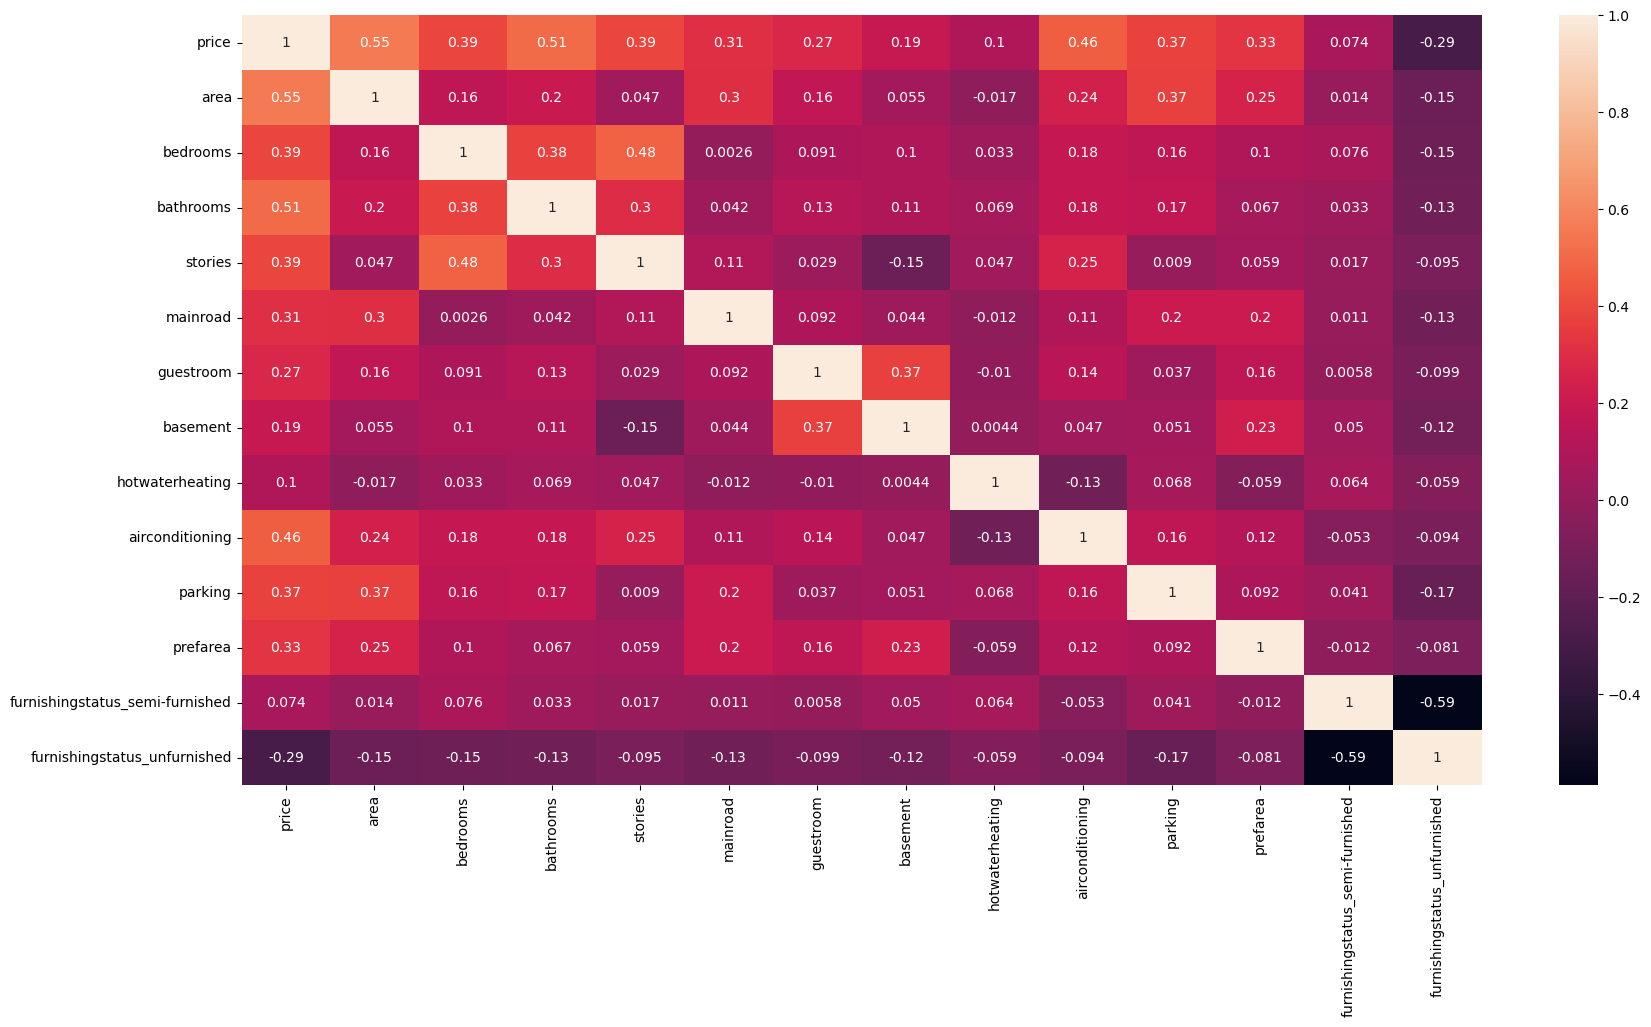

In [201]:
plt.figure(figsize=(20, 10)) 
x= data.corr()
sns.heatmap(x,annot=True)

In [202]:
data.skew()

price                              0.806672
area                               0.807511
bedrooms                           0.002100
bathrooms                          1.452123
stories                            0.428563
mainroad                          -2.065410
guestroom                          1.688419
basement                           0.628590
hotwaterheating                    4.353428
airconditioning                    0.795748
parking                            0.842062
prefarea                           1.254361
furnishingstatus_semi-furnished    0.339635
furnishingstatus_unfurnished       0.741509
dtype: float64

In [203]:
data.kurtosis()

price                               0.093585
area                                0.143462
bedrooms                           -0.624928
bathrooms                           1.117593
stories                            -0.909971
mainroad                            2.274252
guestroom                           0.853877
basement                           -1.610800
hotwaterheating                    17.014764
airconditioning                    -1.371834
parking                            -0.573063
prefarea                           -0.428162
furnishingstatus_semi-furnished    -1.891603
furnishingstatus_unfurnished       -1.455519
dtype: float64

In [204]:
# Select the continuous numerical columns
numeric_cols = ['price', 'area']

# Calculate Skewness and Kurtosis
skew_vals = data[numeric_cols].skew()
kurt_vals = data[numeric_cols].kurtosis()

# Combine into a clean table
stats_df = pd.DataFrame({'Skewness': skew_vals, 'Kurtosis': kurt_vals})
print(stats_df)

       Skewness  Kurtosis
price  0.806672  0.093585
area   0.807511  0.143462


In [205]:
data['price_log'] = np.log1p(data['price'])
data['price_log'] = np.log1p(data['price'])

In [206]:
data['area_sqrt'] = np.sqrt(data['area'])

# Check if the skewness improved (closer to 0)
print(f"Original Skew: {data['area'].skew():.2f}")
print(f"New Skew: {data['area_sqrt'].skew():.2f}")

Original Skew: 0.81
New Skew: 0.41


In [207]:
# Select the continuous numerical columns
numeric_cols = ['price_log', 'area_sqrt']

# Calculate Skewness and Kurtosis
skew_vals = data[numeric_cols].skew()
kurt_vals = data[numeric_cols].kurtosis()

# Combine into a clean table
stats_df = pd.DataFrame({'Skewness': skew_vals, 'Kurtosis': kurt_vals})
print(stats_df)

           Skewness  Kurtosis
price_log  0.010440 -0.401524
area_sqrt  0.411337 -0.418126


In [208]:
# Create an interaction feature
data['area_per_bath'] = data['area_sqrt'] * data['bathrooms']

In [209]:
X = data.drop(['price', 'area', 'price_log'], axis=1) 
y = data['price_log']


print(X.dtypes.head())

bedrooms     int64
bathrooms    int64
stories      int64
mainroad     int64
guestroom    int64
dtype: object


In [210]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Evaluate
preds = model.predict(X_test_scaled)
print(f"R2 Score: {r2_score(y_test, preds):.4f}")

R2 Score: 0.5994


In [211]:
log_preds = model.predict(X_test_scaled)
final_preds = np.expm1(log_preds)
actual_prices = np.expm1(y_test)
mae_dollars = mean_absolute_error(actual_prices, final_preds)

print(f"Mean Absolute Error: ${mae_dollars:,.2f}")

Mean Absolute Error: $961,345.73


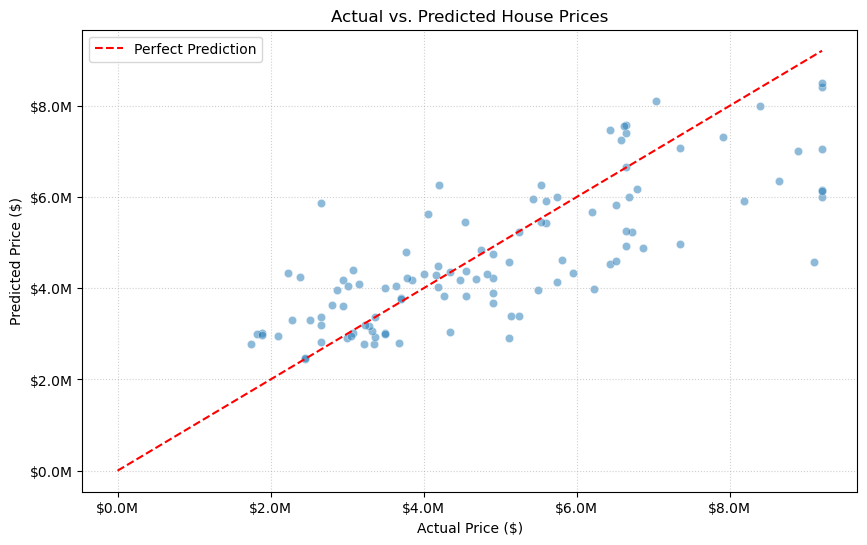

In [212]:
actual_dollars = np.expm1(y_test)
predicted_dollars = np.expm1(model.predict(X_test_scaled))

# 2. Create the Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=actual_dollars, y=predicted_dollars, alpha=0.5)

# 3. Add the 'Perfect Prediction' Line
# A perfect model would have every dot exactly on this 45-degree line
max_val = max(actual_dollars.max(), predicted_dollars.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs. Predicted House Prices')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Format the axes to show millions clearly
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, p: f'${x*1e-6:.1f}M')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()

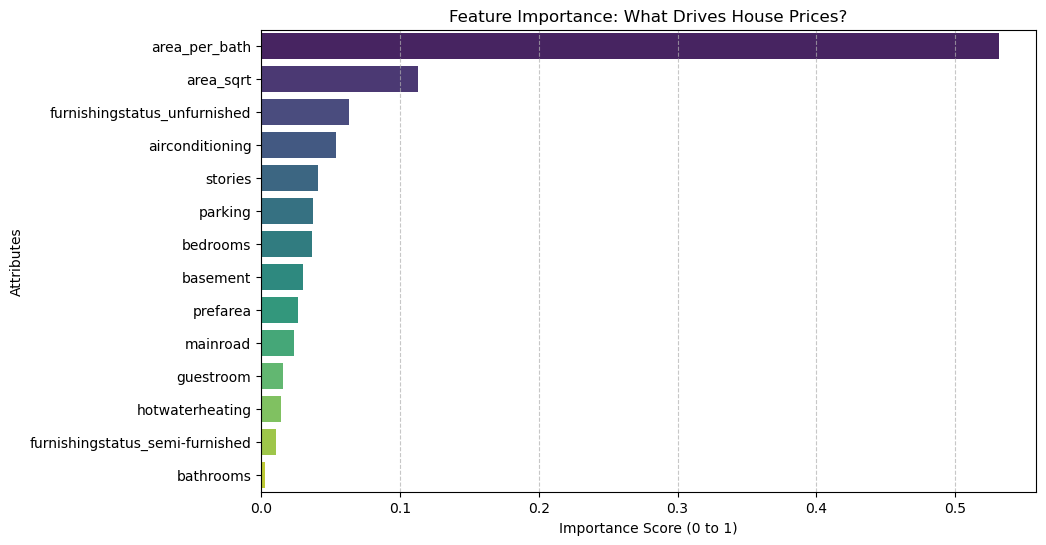

In [213]:
importances = model.feature_importances_
feature_names = X.columns # Ensure this matches the X used in model.fit()

# 2. Create a DataFrame for easy plotting
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, hue='Feature', palette='viridis', legend=False)

plt.title('Feature Importance: What Drives House Prices?')
plt.xlabel('Importance Score (0 to 1)')
plt.ylabel('Attributes')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [214]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,price_log,area_sqrt,area_per_bath
0,9205000,7420,4,2,3,1,0,0,0,1,2,1,0,0,16.035257,86.139422,172.278844
1,9205000,8960,4,3,3,1,0,0,0,1,3,0,0,0,16.035257,94.657277,283.971830
2,9205000,9960,3,2,2,1,0,1,0,0,2,1,1,0,16.035257,99.799800,199.599599
3,9205000,7500,4,2,2,1,0,1,0,1,3,1,0,0,16.035257,86.602540,173.205081
4,9205000,7420,4,1,2,1,1,1,0,1,2,0,0,0,16.035257,86.139422,86.139422


In [215]:
actual_prices = np.expm1(y_test)
final_preds = np.expm1(model.predict(X_test_scaled))

# 2. Calculate Metrics
r2 = r2_score(y_test, model.predict(X_test_scaled)) # Calculated on log for accuracy
mae = mean_absolute_error(actual_prices, final_preds)
rmse = np.sqrt(mean_squared_error(actual_prices, final_preds))

# 3. Create the Summary Table
metrics_data = {
    'Metric': ['R-Squared (R²)', 'Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)'],
    'Value': [f"{r2:.4f}", f"${mae:,.2f}", f"${rmse:,.2f}"],
    'Interpretation': [
        'Higher is better (max 1.0)', 
        'Average dollar amount off', 
        'Penalizes large errors more'
    ]
}

report_df = pd.DataFrame(metrics_data)
print(report_df.to_string(index=False))

                        Metric         Value              Interpretation
                R-Squared (R²)        0.5994  Higher is better (max 1.0)
     Mean Absolute Error (MAE)   $961,345.73   Average dollar amount off
Root Mean Squared Error (RMSE) $1,280,301.72 Penalizes large errors more


In [216]:
def predict_house_price(input_data, model, scaler, feature_columns, exchange_rate=83.50):
    """
    input_data: Dictionary of house attributes
    model: Your trained RandomForestRegressor
    scaler: Your fitted StandardScaler
    feature_columns: The list of columns used in X_train
    """
    # 1. Create a DataFrame from input
    df_input = pd.DataFrame([input_data])
    
    # 2. Apply the same transformations used in training
    if 'area' in df_input.columns:
        df_input['area_sqrt'] = np.sqrt(df_input['area'])
    
    # Create the interaction term
    if 'area_sqrt' in df_input.columns and 'bathrooms' in df_input.columns:
        df_input['area_per_bath'] = df_input['area_sqrt'] * df_input['bathrooms']
        
    # 3. Ensure columns match the training set (handling One-Hot dummies)
    # This adds missing columns as 0 (e.g., if the house isn't 'semi-furnished')
    df_processed = pd.get_dummies(df_input).reindex(columns=feature_columns, fill_value=0)
    
    # 4. Scale the features
    X_scaled = scaler.transform(df_processed)
    
    # 5. Predict and Inverse Log
    log_prediction = model.predict(X_scaled)
    actual_price = np.expm1(log_prediction)[0]
    price_inr = actual_price * exchange_rate
    return price_inr

# --- EXAMPLE USAGE ---
# Define a new house
new_house = {
    'area': 1500,        # Smallest typical lot size
    'bedrooms': 1,       # Minimum utility
    'bathrooms': 1,      # Most significant price dropper
    'stories': 1,
    'mainroad': 0,       # 'No' (mapped to 0)
    'guestroom': 0,
    'basement': 0,
    'hotwaterheating': 0,
    'airconditioning': 0,
    'parking': 0,
    'prefarea': 0,
    'furnishingstatus_semi-furnished': 0,
    'furnishingstatus_unfurnished': 1
}

price_in_rupees = predict_house_price(new_house, model, scaler, X.columns)
print(f"Estimated Market Value: ₹{price_in_rupees:,.2f}")

Estimated Market Value: ₹220,588,107.69


In [217]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,   # High count, but we use early stopping
    max_depth=5,         # Shallower trees than RF to prevent noise-fitting
    learning_rate=0.05,  # Small steps help find the global minimum
    subsample=0.8,       # Use 80% of data per tree to add randomness
    colsample_bytree=0.8,
    random_state=42
)

# 2. Train with Early Stopping
# This stops training when the test score stops improving
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

# 3. Predict and Evaluate (In Dollars)
xgb_log_preds = xgb_model.predict(X_test_scaled)
xgb_final_preds = np.expm1(xgb_log_preds)
actual_prices = np.expm1(y_test)

# 4. Results
print(f"XGBoost R2 Score: {r2_score(y_test, xgb_log_preds):.4f}")
print(f"XGBoost MAE: Rs{mean_absolute_error(actual_prices, xgb_final_preds):,.2f}")

XGBoost R2 Score: 0.6104
XGBoost MAE: Rs973,608.49


In [218]:
import pickle

# Define your 'model pack' - this preserves everything the dashboard needs
model_pack = {
    'model': xgb_model,      # Replace with your actual model variable name
    'scaler': scaler,        # Replace with your fitted StandardScaler variable
    'features': X.columns.tolist() # Keeps the exact column order for prediction
}

# Write the file to your local directory
with open('house_model_pack.pkl', 'wb') as f:
    pickle.dump(model_pack, f)

print("Success: 'house_model_pack.pkl' created and ready for Streamlit!")

Success: 'house_model_pack.pkl' created and ready for Streamlit!
